# SPY Long-Term Multi-Pattern Strategy Backtest

This notebook backtests the Multi-Pattern Confluence Strategy on SPY daily data from 2015-2024.

**Strategy**: Uses 20 pattern detectors across 4 categories (Basic, Harmonic, Complex, Classic) with confluence scoring to generate trading signals.

**Data**: SPY daily OHLCV data (~10 years)

## Configuration

Centralized configuration for data, backtest, strategy, and analysis settings.

In [1]:
CONFIG = {
    # Data settings
    'data': {
        'filename': 'SPY_daily.csv',
        'directory': 'data/raw',
        'columns': ['Open', 'High', 'Low', 'Close', 'Volume'],
    },
    
    # Backtest settings
    'backtest': {
        'initial_capital': 100000,
        'commission': 0.001,  # 0.1% commission
        'exclusive_orders': True,
    },
    
    # Strategy parameters - optimized for daily timeframe
    'strategy': {
        'min_confidence': 0.55,        # Slightly lower threshold for daily data
        'min_confluence_count': 2,     # At least 2 patterns must agree
        'risk_per_trade': 0.02,        # 2% risk per trade
        'max_open_positions': 3,       # Fewer positions for swing trading
        'use_regime_filter': True,     # Use market regime filter
    },
    
    # Benchmark comparison settings
    'benchmark': {
        'risk_free_rate': 0.02,       # 2% annual risk-free rate
        'periods_per_year': 252,      # Trading days per year
    },
    
    # Risk metrics settings
    'risk': {
        'var_confidence_levels': [0.95, 0.99],
        'rolling_beta_window': 63,    # ~3 months
    },
    
    # Visualization settings
    'visualization': {
        'figure_size': (14, 10),
        'style': 'seaborn-v0_8-whitegrid',
        'dpi': 150,
    },
    
    # Output settings
    'output': {
        'directory': 'reports',
        'plot_filename': 'spy_backtest_results.html',
    },
}

## 1. Setup and Imports

In [2]:
import sys
from pathlib import Path

# Setup project root
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import backtesting.py integration
from src.strategies.backtest_py import BacktestPyRunner, MultiPatternStrategyOptimized

# Import visualization
from src.visualization import ReportGenerator

# Import helpers
from src.utils.notebook_helpers import (
    get_data_path,
    get_output_path,
    print_config,
    print_backtest_summary,
)

# Print configuration
print_config(CONFIG, "SPY Long-Term Backtest Configuration")

Loading BokehJS ...

📋 SPY Long-Term Backtest Configuration

DATA:
  filename: SPY_daily.csv
  directory: data/raw
  columns: ['Open', 'High', 'Low', 'Close', 'Volume']

BACKTEST:
  initial_capital: 100000
  commission: 0.001
  exclusive_orders: True

STRATEGY:
  min_confidence: 0.55
  min_confluence_count: 2
  risk_per_trade: 0.02
  max_open_positions: 3
  use_regime_filter: True

BENCHMARK:
  risk_free_rate: 0.02
  periods_per_year: 252

RISK:
  var_confidence_levels: [0.95, 0.99]
  rolling_beta_window: 63

VISUALIZATION:
  figure_size: (14, 10)
  style: seaborn-v0_8-whitegrid
  dpi: 150

OUTPUT:
  directory: reports
  plot_filename: spy_backtest_results.html


## 2. Load and Prepare Data

In [3]:
# Load SPY daily data
data_path = get_data_path(CONFIG, project_root)

df = pd.read_csv(data_path, index_col=0, parse_dates=True)

# Ensure required columns with proper casing
df.columns = [c.capitalize() for c in df.columns]

# Display basic info
print("="*60)
print("SPY Daily Data Summary")
print("="*60)
print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Total Trading Days: {len(df)}")
print(f"Years of Data: {(df.index.max() - df.index.min()).days / 365.25:.1f}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

SPY Daily Data Summary
Date Range: 2015-01-02 to 2024-12-31
Total Trading Days: 2516
Years of Data: 10.0

Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

Data shape: (2516, 5)

First 5 rows:


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,170.589615,171.793709,169.551612,171.378508,121465900
2015-01-05,167.508820,169.709381,167.201575,169.543303,169632600
2015-01-06,165.931061,168.339223,165.133869,167.816066,209151400
2015-01-07,167.998795,168.339263,166.811325,167.259737,125346700
2015-01-08,170.979904,171.195817,169.393845,169.410444,147217800


In [4]:
# Data statistics
print("Price Statistics:")
print(df[['Open', 'High', 'Low', 'Close']].describe().round(2))

Price Statistics:
          Open     High      Low    Close
count  2516.00  2516.00  2516.00  2516.00
mean    310.27   311.95   308.44   310.31
std     114.48   115.04   113.85   114.49
min     154.54   156.03   152.88   154.98
25%     212.24   212.82   211.43   212.17
50%     273.24   273.96   272.21   273.21
75%     399.26   401.57   396.66   399.33
max     598.62   599.98   597.96   598.74


In [5]:
# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()

# Calculate annual returns
annual_returns = df['Close'].resample('YE').last().pct_change().dropna()

print("\nAnnual Returns:")
for year, ret in annual_returns.items():
    print(f"  {year.year}: {ret*100:.2f}%")

print(f"\nAverage Annual Return: {annual_returns.mean()*100:.2f}%")
print(f"Annual Return Std Dev: {annual_returns.std()*100:.2f}%")


Annual Returns:
  2016: 12.00%
  2017: 21.71%
  2018: -4.57%
  2019: 31.22%
  2020: 18.33%
  2021: 28.73%
  2022: -18.18%
  2023: 26.18%
  2024: 24.89%

Average Annual Return: 15.59%
Annual Return Std Dev: 16.66%


## 3. Data Visualization

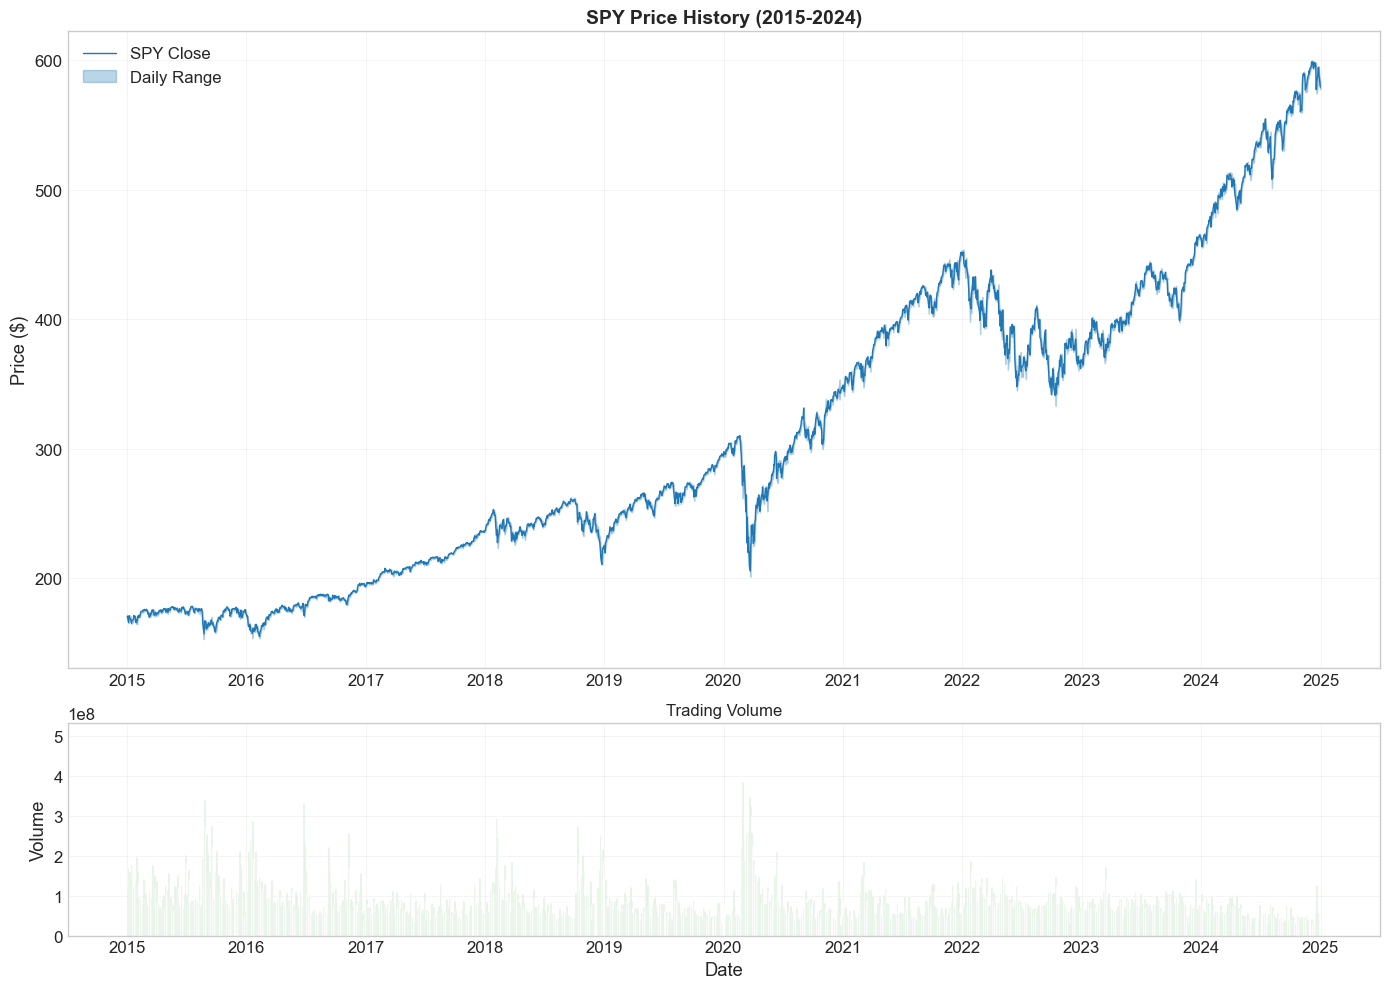

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set style from config
plt.style.use(CONFIG['visualization']['style'])
plt.rcParams['figure.figsize'] = CONFIG['visualization']['figure_size']
plt.rcParams['font.size'] = 10

# Create price chart
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Price chart
ax1 = axes[0]
ax1.plot(df.index, df['Close'], linewidth=1, color='#1f77b4', label='SPY Close')
ax1.fill_between(df.index, df['Low'], df['High'], alpha=0.3, color='#1f77b4', label='Daily Range')
ax1.set_title('SPY Price History (2015-2024)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Volume chart
ax2 = axes[1]
ax2.bar(df.index, df['Volume'], width=1, color='#2ca02c', alpha=0.7)
ax2.set_title('Trading Volume', fontsize=12)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

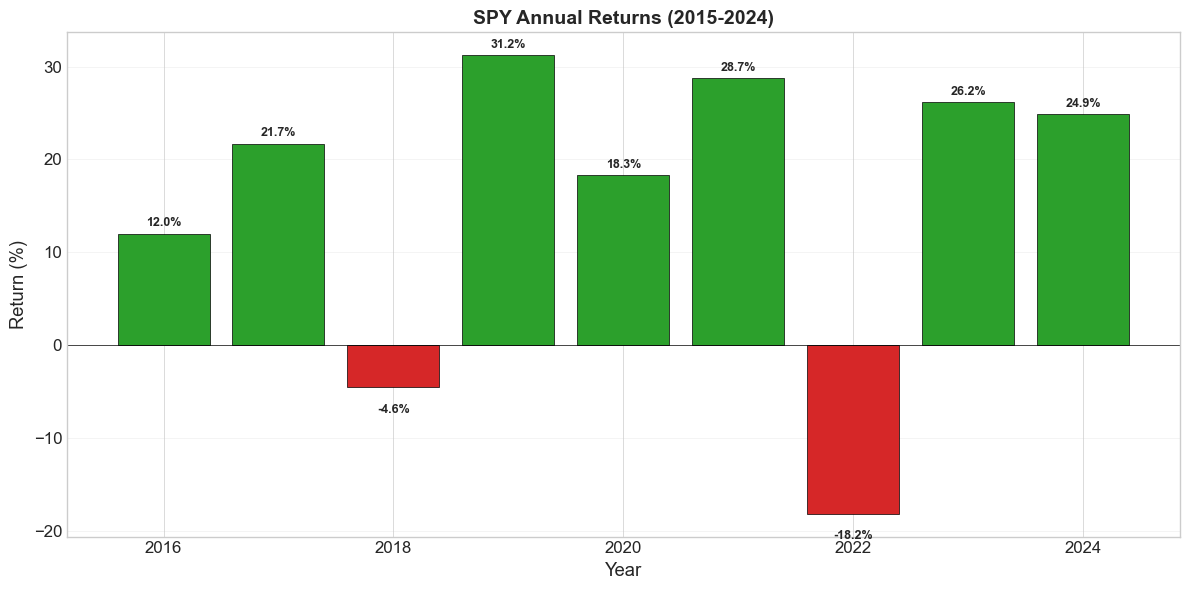

In [7]:
# Annual returns bar chart
fig, ax = plt.subplots(figsize=(12, 6))

years = [y.year for y in annual_returns.index]
returns = [r * 100 for r in annual_returns.values]
colors = ['#2ca02c' if r >= 0 else '#d62728' for r in returns]

bars = ax.bar(years, returns, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('SPY Annual Returns (2015-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Return (%)')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, ret in zip(bars, returns):
    height = bar.get_height()
    ax.annotate(f'{ret:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Strategy Configuration

The Multi-Pattern Strategy uses confluence scoring from 20 pattern detectors.

**Key Parameters:**
- `min_confidence`: Minimum confidence threshold for signals (default: 0.60)
- `min_confluence_count`: Minimum patterns that must agree (default: 2)
- `risk_per_trade`: Risk per trade as fraction of equity (default: 2%)
- `max_open_positions`: Maximum concurrent positions (default: 5)
- `use_regime_filter`: Filter by market regime (default: True)

In [8]:
# Extract config values
INITIAL_CAPITAL = CONFIG['backtest']['initial_capital']
COMMISSION = CONFIG['backtest']['commission']
strategy_params = CONFIG['strategy'].copy()

print("Backtest Configuration:")
print("="*40)
print(f"Initial Capital: ${INITIAL_CAPITAL:,.0f}")
print(f"Commission: {COMMISSION*100:.1f}%")
print(f"\nStrategy Parameters:")
for key, value in strategy_params.items():
    print(f"  {key}: {value}")

Backtest Configuration:
Initial Capital: $100,000
Commission: 0.1%

Strategy Parameters:
  min_confidence: 0.55
  min_confluence_count: 2
  risk_per_trade: 0.02
  max_open_positions: 3
  use_regime_filter: True


## 5. Run Backtest

In [9]:
# Prepare data for backtest (remove the Daily_Return column we added)
df_backtest = df[CONFIG['data']['columns']].copy()

print("Running Multi-Pattern Strategy Backtest...")
print("This may take a few minutes for 10 years of daily data.\n")

# Initialize runner
runner = BacktestPyRunner(
    data=df_backtest,
    cash=INITIAL_CAPITAL,
    commission=COMMISSION,
    exclusive_orders=CONFIG['backtest']['exclusive_orders']
)

# Run backtest
results = runner.run(**strategy_params)

print("\nBacktest completed!")

Running Multi-Pattern Strategy Backtest...
This may take a few minutes for 10 years of daily data.

Running backtest on 2516 bars...


Backtest.run:   0%|          | 0/2515 [00:00<?, ?bar/s]

INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #1: LONG @ 171.98 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #2: LONG @ 173.21 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #3: LONG @ 176.13 | Patterns: 2 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #4: LONG @ 177.75 | Patterns: 2 | Confidence: 0.62


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #5: SHORT @ 176.11 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #6: LONG @ 174.83 | Patterns: 2 | Confidence: 0.57


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #7: SHORT @ 164.46 | Patterns: 2 | Confidence: 0.57


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #8: LONG @ 172.34 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #9: SHORT @ 177.21 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #10: LONG @ 182.10 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #11: SHORT @ 187.08 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #12: LONG @ 188.48 | Patterns: 2 | Confidence: 0.57


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #13: SHORT @ 212.15 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #14: LONG @ 213.77 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #15: SHORT @ 210.86 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #16: LONG @ 214.56 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #17: SHORT @ 214.53 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #18: LONG @ 246.12 | Patterns: 3 | Confidence: 0.72


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #19: SHORT @ 228.15 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #20: LONG @ 243.59 | Patterns: 2 | Confidence: 0.55


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #21: SHORT @ 248.83 | Patterns: 2 | Confidence: 0.78


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #22: LONG @ 221.40 | Patterns: 4 | Confidence: 0.69


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #23: SHORT @ 222.81 | Patterns: 3 | Confidence: 0.73


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #24: LONG @ 240.64 | Patterns: 2 | Confidence: 0.73


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #25: SHORT @ 254.86 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #26: LONG @ 264.12 | Patterns: 2 | Confidence: 0.57


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #27: SHORT @ 267.62 | Patterns: 3 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #28: LONG @ 267.40 | Patterns: 3 | Confidence: 0.73


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #29: SHORT @ 271.71 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #30: LONG @ 273.55 | Patterns: 2 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #31: LONG @ 264.30 | Patterns: 3 | Confidence: 0.67


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #32: LONG @ 246.79 | Patterns: 3 | Confidence: 0.67


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #33: LONG @ 270.27 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #34: SHORT @ 303.64 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #35: LONG @ 346.00 | Patterns: 4 | Confidence: 0.62


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #36: SHORT @ 344.26 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #37: SHORT @ 353.50 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #38: LONG @ 395.33 | Patterns: 2 | Confidence: 0.62


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #39: LONG @ 384.24 | Patterns: 2 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #40: SHORT @ 399.13 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #41: LONG @ 426.60 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #42: SHORT @ 390.93 | Patterns: 2 | Confidence: 0.78


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #43: LONG @ 382.17 | Patterns: 3 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #44: SHORT @ 391.45 | Patterns: 2 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #45: LONG @ 377.67 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #46: SHORT @ 384.63 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #47: LONG @ 395.03 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #48: SHORT @ 394.34 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #49: SHORT @ 391.84 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #50: LONG @ 404.53 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #51: SHORT @ 403.94 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #52: SHORT @ 413.02 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #53: LONG @ 427.08 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #54: SHORT @ 425.63 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #55: LONG @ 431.98 | Patterns: 2 | Confidence: 0.65


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #56: SHORT @ 419.28 | Patterns: 3 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #57: LONG @ 417.48 | Patterns: 3 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #58: SHORT @ 421.49 | Patterns: 2 | Confidence: 0.70


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #59: LONG @ 423.80 | Patterns: 3 | Confidence: 0.67


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #60: SHORT @ 418.14 | Patterns: 3 | Confidence: 0.72


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #61: LONG @ 495.26 | Patterns: 2 | Confidence: 0.73


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #62: SHORT @ 531.52 | Patterns: 2 | Confidence: 0.78


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #63: LONG @ 534.68 | Patterns: 2 | Confidence: 0.60


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #64: SHORT @ 523.34 | Patterns: 2 | Confidence: 0.68


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #65: LONG @ 568.53 | Patterns: 2 | Confidence: 0.57


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #66: SHORT @ 560.15 | Patterns: 2 | Confidence: 0.75


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #67: LONG @ 598.40 | Patterns: 3 | Confidence: 0.67


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #68: SHORT @ 577.53 | Patterns: 3 | Confidence: 0.72


INFO:src.strategies.backtest_py.multi_pattern_strategy:Signal #69: LONG @ 584.29 | Patterns: 4 | Confidence: 0.65



BACKTEST SUMMARY
Start Date: 2015-01-02 00:00:00
End Date: 2024-12-31 00:00:00
Duration: 3651 days 00:00:00

Initial Capital: $100,000.00
Final Equity: $86,331.12
Final Return: -13.67%

Total Trades: 68
Win Rate: 27.94%
Best Trade: 12.80%
Worst Trade: -11.55%
Avg Trade: -1.42%

Max Drawdown: -14.57%
Sharpe Ratio: -0.57
Sortino Ratio: -0.74
Calmar Ratio: -0.10


Backtest completed!


## 6. Performance Results

In [10]:
# Display key metrics
stats = results['stats']

print("="*60)
print("BACKTEST PERFORMANCE SUMMARY")
print("="*60)
print(f"\n{'Return Metrics':^40}")
print("-"*40)
print(f"Total Return:          {stats.get('Return [%]', 'N/A'):.2f}%" if isinstance(stats.get('Return [%]'), (int, float)) else f"Total Return:          {stats.get('Return [%]', 'N/A')}")
print(f"Buy & Hold Return:     {stats.get('Buy & Hold Return [%]', 'N/A'):.2f}%" if isinstance(stats.get('Buy & Hold Return [%]'), (int, float)) else f"Buy & Hold Return:     {stats.get('Buy & Hold Return [%]', 'N/A')}")
print(f"Annual Return:         {stats.get('Return (Ann.) [%]', 'N/A'):.2f}%" if isinstance(stats.get('Return (Ann.) [%]'), (int, float)) else f"Annual Return:         {stats.get('Return (Ann.) [%]', 'N/A')}")

print(f"\n{'Risk Metrics':^40}")
print("-"*40)
print(f"Sharpe Ratio:          {stats.get('Sharpe Ratio', 'N/A'):.2f}" if isinstance(stats.get('Sharpe Ratio'), (int, float)) else f"Sharpe Ratio:          {stats.get('Sharpe Ratio', 'N/A')}")
print(f"Sortino Ratio:         {stats.get('Sortino Ratio', 'N/A'):.2f}" if isinstance(stats.get('Sortino Ratio'), (int, float)) else f"Sortino Ratio:         {stats.get('Sortino Ratio', 'N/A')}")
print(f"Max Drawdown:          {stats.get('Max. Drawdown [%]', 'N/A'):.2f}%" if isinstance(stats.get('Max. Drawdown [%]'), (int, float)) else f"Max Drawdown:          {stats.get('Max. Drawdown [%]', 'N/A')}")
print(f"Volatility (Ann.):     {stats.get('Volatility (Ann.) [%]', 'N/A'):.2f}%" if isinstance(stats.get('Volatility (Ann.) [%]'), (int, float)) else f"Volatility (Ann.):     {stats.get('Volatility (Ann.) [%]', 'N/A')}")

print(f"\n{'Trade Statistics':^40}")
print("-"*40)
print(f"Total Trades:          {stats.get('# Trades', 'N/A')}")
print(f"Win Rate:              {stats.get('Win Rate [%]', 'N/A'):.1f}%" if isinstance(stats.get('Win Rate [%]'), (int, float)) else f"Win Rate:              {stats.get('Win Rate [%]', 'N/A')}")
print(f"Best Trade:            {stats.get('Best Trade [%]', 'N/A'):.2f}%" if isinstance(stats.get('Best Trade [%]'), (int, float)) else f"Best Trade:            {stats.get('Best Trade [%]', 'N/A')}")
print(f"Worst Trade:           {stats.get('Worst Trade [%]', 'N/A'):.2f}%" if isinstance(stats.get('Worst Trade [%]'), (int, float)) else f"Worst Trade:           {stats.get('Worst Trade [%]', 'N/A')}")
print(f"Avg. Trade:            {stats.get('Avg. Trade [%]', 'N/A'):.2f}%" if isinstance(stats.get('Avg. Trade [%]'), (int, float)) else f"Avg. Trade:            {stats.get('Avg. Trade [%]', 'N/A')}")
print(f"Max. Trade Duration:   {stats.get('Max. Trade Duration', 'N/A')}")
print(f"Avg. Trade Duration:   {stats.get('Avg. Trade Duration', 'N/A')}")

print(f"\n{'Other Metrics':^40}")
print("-"*40)
print(f"Final Equity:          ${stats.get('Equity Final [$]', 'N/A'):,.0f}" if isinstance(stats.get('Equity Final [$]'), (int, float)) else f"Final Equity:          {stats.get('Equity Final [$]', 'N/A')}")
print(f"Peak Equity:           ${stats.get('Equity Peak [$]', 'N/A'):,.0f}" if isinstance(stats.get('Equity Peak [$]'), (int, float)) else f"Peak Equity:           {stats.get('Equity Peak [$]', 'N/A')}")

BACKTEST PERFORMANCE SUMMARY

             Return Metrics             
----------------------------------------
Total Return:          -13.67%
Buy & Hold Return:     239.57%
Annual Return:         -1.46%

              Risk Metrics              
----------------------------------------
Sharpe Ratio:          -0.57
Sortino Ratio:         -0.74
Max Drawdown:          -14.57%
Volatility (Ann.):     2.55%

            Trade Statistics            
----------------------------------------
Total Trades:          68
Win Rate:              27.9%
Best Trade:            12.80%
Worst Trade:           -11.55%
Avg. Trade:            -1.42%
Max. Trade Duration:   286 days 00:00:00
Avg. Trade Duration:   43 days 00:00:00

             Other Metrics              
----------------------------------------
Final Equity:          $86,331
Peak Equity:           $101,058


In [11]:
# Display all stats
print("\n" + "="*60)
print("DETAILED STATISTICS")
print("="*60)
for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


DETAILED STATISTICS
Start: 2015-01-02 00:00:00
End: 2024-12-31 00:00:00
Duration: 3651 days 00:00:00
Exposure Time [%]: 80.4849
Equity Final [$]: 86331.1224
Equity Peak [$]: 101058.4544
Commissions [$]: 2408.1977
Return [%]: -13.6689
Buy & Hold Return [%]: 239.5737
Return (Ann.) [%]: -1.4614
Volatility (Ann.) [%]: 2.5514
CAGR [%]: -1.0094
Sharpe Ratio: -0.5728
Sortino Ratio: -0.7437
Calmar Ratio: -0.1003
Alpha [%]: -13.6455
Beta: -0.0001
Max. Drawdown [%]: -14.5731
Avg. Drawdown [%]: -4.0725
Max. Drawdown Duration: 3416 days 00:00:00
Avg. Drawdown Duration: 896 days 00:00:00
# Trades: 68
Win Rate [%]: 27.9412
Best Trade [%]: 12.7975
Worst Trade [%]: -11.5478
Avg. Trade [%]: -1.4220
Max. Trade Duration: 286 days 00:00:00
Avg. Trade Duration: 43 days 00:00:00
Profit Factor: 0.4365
Expectancy [%]: -1.3179
SQN: -2.0632
Kelly Criterion: -0.3016
_strategy: MultiPatternStrategy(min_confidence=0.55,min_confluence_count=2,risk_per_trade=0.02,max_open_positions=3,use_regime_filter=True)
_equity

## 7. Visualizations

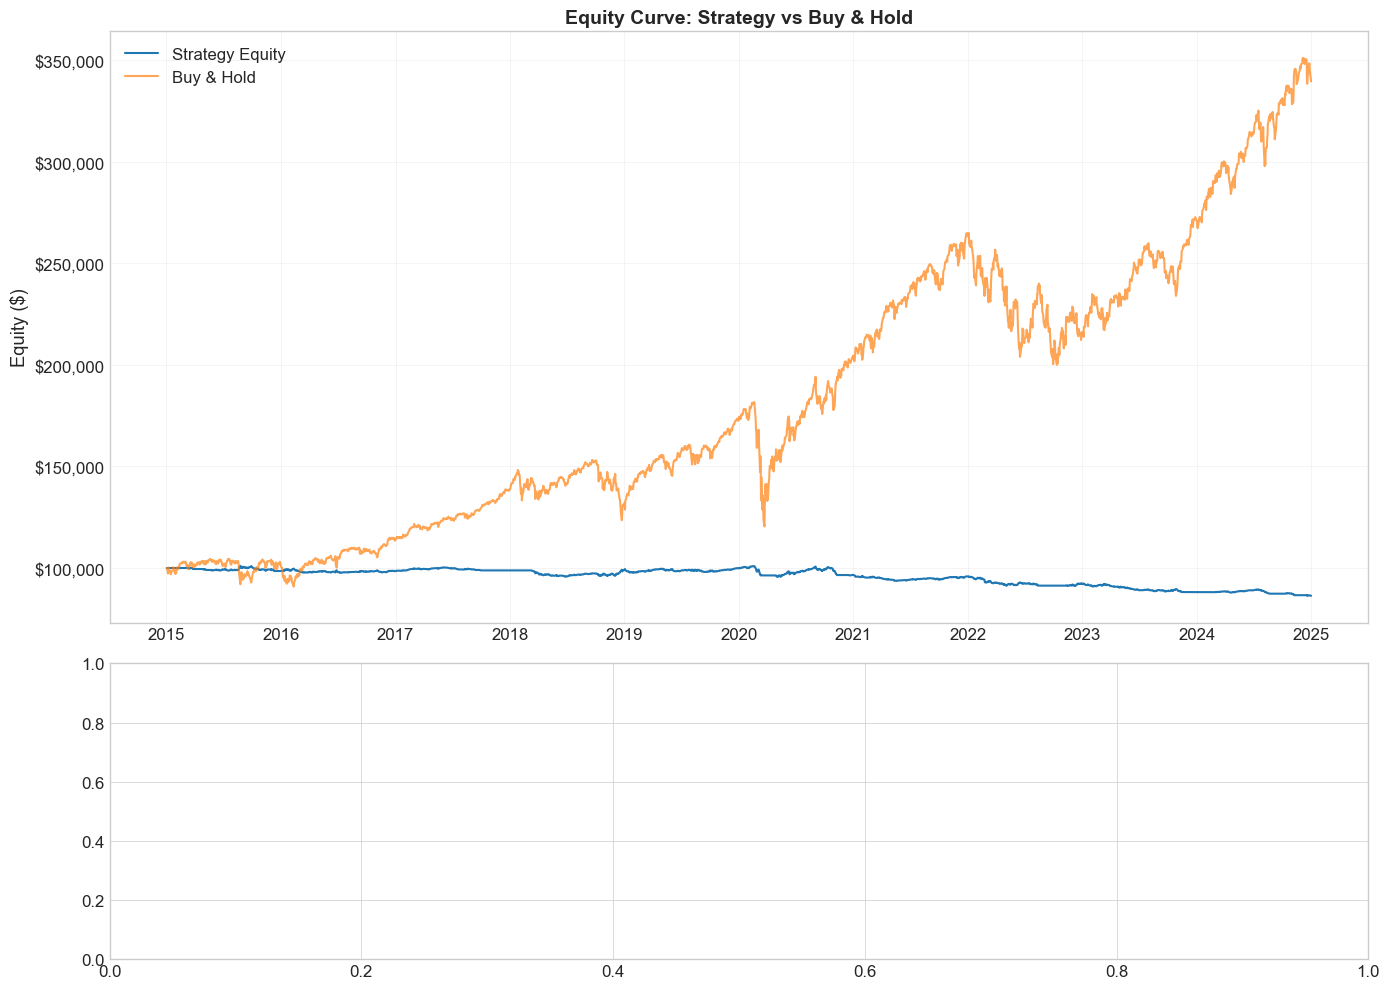

In [12]:
# Plot equity curve
if 'equity_curve' in results:
    equity_df = results['equity_curve']
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})
    
    # Equity curve
    ax1 = axes[0]
    ax1.plot(equity_df.index, equity_df['Equity'], linewidth=1.5, color='#1f77b4', label='Strategy Equity')
    
    # Buy & Hold comparison
    initial_price = df_backtest['Close'].iloc[0]
    final_price = df_backtest['Close']
    buy_hold_equity = INITIAL_CAPITAL * (final_price / initial_price)
    ax1.plot(buy_hold_equity.index, buy_hold_equity, linewidth=1.5, color='#ff7f0e', label='Buy & Hold', alpha=0.7)
    
    ax1.set_title('Equity Curve: Strategy vs Buy & Hold', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Equity ($)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Drawdown
    ax2 = axes[1]
    if 'Drawdown' in equity_df.columns:
        ax2.fill_between(equity_df.index, equity_df['Drawdown'] * 100, 0, 
                         color='#d62728', alpha=0.5, label='Drawdown')
        ax2.set_title('Strategy Drawdown', fontsize=12)
        ax2.set_ylabel('Drawdown (%)')
        ax2.set_xlabel('Date')
        ax2.legend(loc='lower left')
        ax2.grid(True, alpha=0.3)
        ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
else:
    print("Equity curve data not available. Plotting from backtest results...")
    # Alternative: use backtesting.py's built-in plot
    try:
        output_path = get_output_path(CONFIG, project_root, CONFIG['output']['plot_filename'])
        runner.bt.plot(filename=str(output_path), open_browser=False)
        print(f"Plot saved to '{output_path}'")
    except Exception as e:
        print(f"Could not generate plot: {e}")

In [13]:
# Trade analysis
if 'trades' in results and results['trades'] is not None:
    trades_df = results['trades']
    
    if len(trades_df) > 0:
        print("="*60)
        print("TRADE ANALYSIS")
        print("="*60)
        
        # Trade distribution
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Trade PnL distribution
        ax1 = axes[0, 0]
        if 'PnL' in trades_df.columns:
            pnl = trades_df['PnL']
            wins = pnl[pnl > 0]
            losses = pnl[pnl < 0]
            ax1.hist(wins, bins=20, color='#2ca02c', alpha=0.7, label=f'Wins ({len(wins)})')
            ax1.hist(losses, bins=20, color='#d62728', alpha=0.7, label=f'Losses ({len(losses)})')
            ax1.axvline(x=0, color='black', linewidth=1)
            ax1.set_title('Trade PnL Distribution', fontsize=12)
            ax1.set_xlabel('PnL ($)')
            ax1.set_ylabel('Frequency')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        
        # Trade returns distribution
        ax2 = axes[0, 1]
        if 'ReturnPct' in trades_df.columns:
            returns = trades_df['ReturnPct'] * 100
            ax2.hist(returns, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
            ax2.axvline(x=0, color='red', linewidth=1, linestyle='--')
            ax2.set_title('Trade Return % Distribution', fontsize=12)
            ax2.set_xlabel('Return (%)')
            ax2.set_ylabel('Frequency')
            ax2.grid(True, alpha=0.3)
        
        # Trades over time
        ax3 = axes[1, 0]
        if 'EntryTime' in trades_df.columns:
            trades_df_sorted = trades_df.sort_values('EntryTime')
            cumulative_pnl = trades_df_sorted['PnL'].cumsum()
            ax3.plot(trades_df_sorted['EntryTime'], cumulative_pnl, 
                    linewidth=1.5, color='#1f77b4')
            ax3.fill_between(trades_df_sorted['EntryTime'], 0, cumulative_pnl, 
                            where=(cumulative_pnl >= 0), color='#2ca02c', alpha=0.3)
            ax3.fill_between(trades_df_sorted['EntryTime'], 0, cumulative_pnl, 
                            where=(cumulative_pnl < 0), color='#d62728', alpha=0.3)
            ax3.set_title('Cumulative Trade PnL', fontsize=12)
            ax3.set_xlabel('Date')
            ax3.set_ylabel('Cumulative PnL ($)')
            ax3.grid(True, alpha=0.3)
            ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        # Trade duration vs PnL
        ax4 = axes[1, 1]
        if 'Duration' in trades_df.columns and 'PnL' in trades_df.columns:
            durations = trades_df['Duration'].dt.days if hasattr(trades_df['Duration'].dt, 'days') else trades_df['Duration']
            colors = ['#2ca02c' if pnl > 0 else '#d62728' for pnl in trades_df['PnL']]
            ax4.scatter(durations, trades_df['PnL'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
            ax4.axhline(y=0, color='black', linewidth=0.5)
            ax4.set_title('Trade Duration vs PnL', fontsize=12)
            ax4.set_xlabel('Duration (days)')
            ax4.set_ylabel('PnL ($)')
            ax4.grid(True, alpha=0.3)
            ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        plt.tight_layout()
        plt.show()
        
        # Trade table (first 20 trades)
        print("\nFirst 20 Trades:")
        display_cols = ['EntryTime', 'ExitTime', 'EntryPrice', 'ExitPrice', 'PnL', 'ReturnPct']
        display_cols = [c for c in display_cols if c in trades_df.columns]
        print(trades_df[display_cols].head(20).to_string())
    else:
        print("No trades were executed during the backtest period.")
else:
    print("Trade data not available in results.")

No trades were executed during the backtest period.


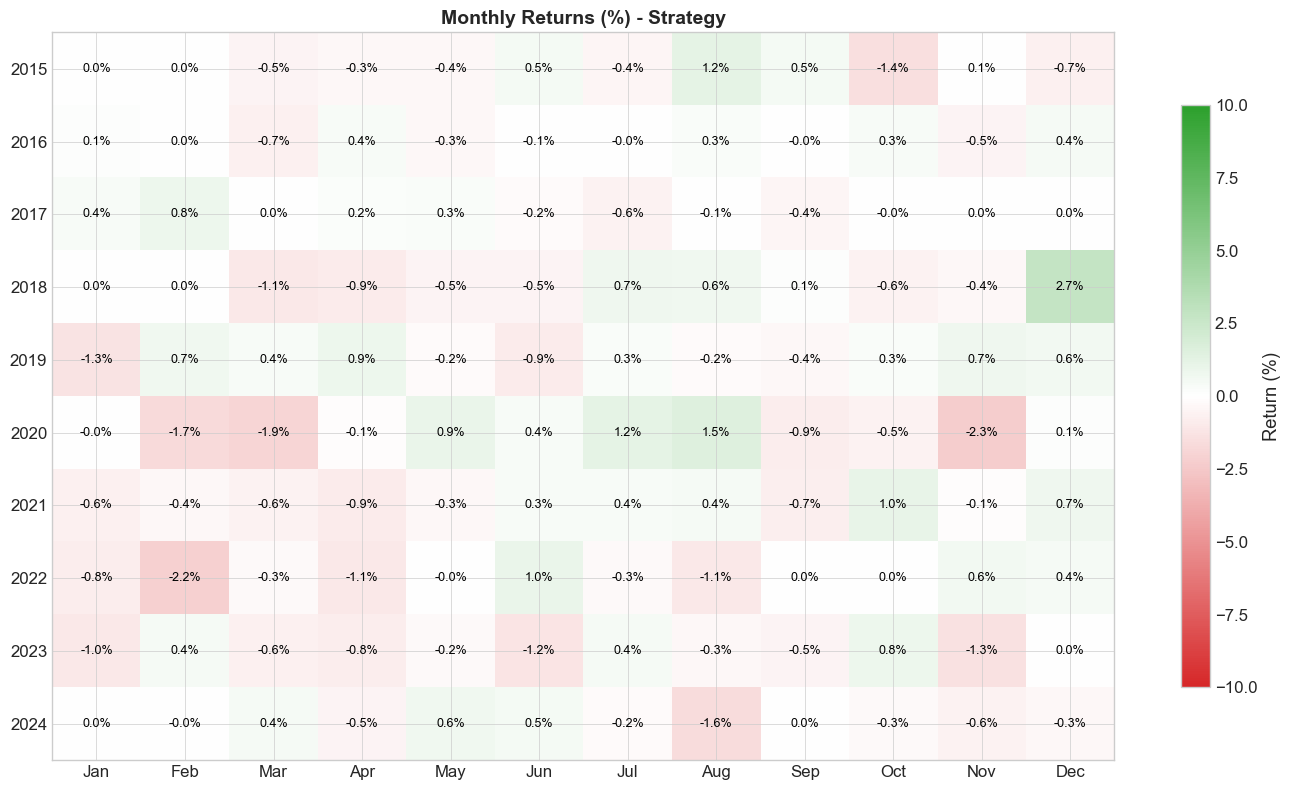

In [14]:
# Monthly returns heatmap
if 'equity_curve' in results:
    equity_df = results['equity_curve']
    
    # Calculate daily returns from equity
    equity_df['DailyReturn'] = equity_df['Equity'].pct_change()
    
    # Calculate monthly returns
    monthly_returns = equity_df['DailyReturn'].resample('ME').apply(lambda x: (1 + x).prod() - 1)
    monthly_returns_pct = monthly_returns * 100
    
    # Create month-year pivot table
    monthly_df = pd.DataFrame({
        'Year': monthly_returns_pct.index.year,
        'Month': monthly_returns_pct.index.month,
        'Return': monthly_returns_pct.values
    })
    
    pivot_table = monthly_df.pivot(index='Year', columns='Month', values='Return')
    pivot_table.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(14, 8))
    
    import matplotlib.colors as mcolors
    cmap = mcolors.LinearSegmentedColormap.from_list('custom', 
        ['#d62728', '#ffffff', '#2ca02c'], N=256)
    
    im = ax.imshow(pivot_table.values, cmap=cmap, aspect='auto', 
                   vmin=-10, vmax=10)
    
    # Labels
    ax.set_xticks(range(12))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticks(range(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index)
    
    # Add text annotations
    for i in range(len(pivot_table.index)):
        for j in range(12):
            val = pivot_table.iloc[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > 5 else 'black'
                text = ax.text(j, i, f'{val:.1f}%',
                              ha='center', va='center', color=color, fontsize=9)
    
    ax.set_title('Monthly Returns (%) - Strategy', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Return (%)', shrink=0.8)
    plt.tight_layout()
    plt.show()

## 8. Summary and Analysis

In [15]:
# Calculate buy & hold metrics for comparison
initial_price = df_backtest['Close'].iloc[0]
final_price = df_backtest['Close'].iloc[-1]
buy_hold_return = (final_price / initial_price - 1) * 100
years = (df_backtest.index[-1] - df_backtest.index[0]).days / 365.25
buy_hold_annual = ((final_price / initial_price) ** (1/years) - 1) * 100

# Strategy metrics
strategy_return = stats.get('Return [%]', 0)
strategy_annual = stats.get('Return (Ann.) [%]', 0)
sharpe = stats.get('Sharpe Ratio', 0)
max_dd = stats.get('Max. Drawdown [%]', 0)
win_rate = stats.get('Win Rate [%]', 0)
total_trades = stats.get('# Trades', 0)

print("="*70)
print("STRATEGY vs BUY & HOLD COMPARISON")
print("="*70)
print(f"\n{'Metric':<30} {'Strategy':<20} {'Buy & Hold':<20}")
print("-"*70)
print(f"{'Total Return':<30} {strategy_return:>18.2f}% {buy_hold_return:>18.2f}%")
print(f"{'Annualized Return':<30} {strategy_annual:>18.2f}% {buy_hold_annual:>18.2f}%")
print(f"{'Sharpe Ratio':<30} {sharpe:>18.2f} {'N/A':>18}")
print(f"{'Max Drawdown':<30} {max_dd:>18.2f}% {'N/A':>18}")
print(f"{'Total Trades':<30} {total_trades:>18} {'N/A':>18}")
print(f"{'Win Rate':<30} {win_rate:>17.1f}% {'N/A':>18}")

print("\n" + "="*70)
print("KEY TAKEAWAYS")
print("="*70)

if strategy_return > buy_hold_return:
    print(f"✓ Strategy OUTPERFORMED Buy & Hold by {strategy_return - buy_hold_return:.2f}%")
else:
    print(f"✗ Strategy UNDERPERFORMED Buy & Hold by {buy_hold_return - strategy_return:.2f}%")

if sharpe > 1:
    print(f"✓ Good risk-adjusted returns (Sharpe > 1)")
elif sharpe > 0.5:
    print(f"○ Moderate risk-adjusted returns (Sharpe > 0.5)")
else:
    print(f"✗ Low risk-adjusted returns (Sharpe < 0.5)")

if max_dd > -20:
    print(f"✓ Controlled drawdown (< 20%)")
elif max_dd > -35:
    print(f"○ Moderate drawdown (20-35%)")
else:
    print(f"✗ Significant drawdown (> 35%)")

if win_rate > 50:
    print(f"✓ Positive win rate ({win_rate:.1f}%)")
else:
    print(f"✗ Win rate below 50% ({win_rate:.1f}%)")

STRATEGY vs BUY & HOLD COMPARISON

Metric                         Strategy             Buy & Hold          
----------------------------------------------------------------------
Total Return                               -13.67%             239.57%
Annualized Return                           -1.46%              13.01%
Sharpe Ratio                                -0.57                N/A
Max Drawdown                               -14.57%                N/A
Total Trades                                   68                N/A
Win Rate                                    27.9%                N/A

KEY TAKEAWAYS
✗ Strategy UNDERPERFORMED Buy & Hold by 253.24%
✗ Low risk-adjusted returns (Sharpe < 0.5)
✓ Controlled drawdown (< 20%)
✗ Win rate below 50% (27.9%)


## 9. Benchmark Comparison (Alpha/Beta Analysis)

This section answers the critical question: **Is this the market growing or is my strategy being smart?**

Key metrics:
- **Alpha**: Excess return after adjusting for market exposure (positive = skill)
- **Beta**: Sensitivity to market movements (< 1 = defensive, > 1 = aggressive)
- **Information Ratio**: Risk-adjusted excess return vs benchmark
- **Tracking Error**: How closely the strategy follows the benchmark

In [16]:
# Import benchmark comparison module
from src.backtest import BenchmarkComparison, RiskMetrics, DrawdownAnalyzer

# Calculate strategy returns from equity curve
if 'equity_curve' in results and results['equity_curve'] is not None:
    equity_df = results['equity_curve']
    strategy_returns = equity_df['Equity'].pct_change().dropna()
else:
    # Calculate from trades
    strategy_returns = pd.Series(dtype=float)

# Calculate benchmark (SPY) returns
benchmark_returns = df_backtest['Close'].pct_change().dropna()

# Align dates
aligned_strategy = strategy_returns
aligned_benchmark = benchmark_returns.reindex(aligned_strategy.index).dropna()
aligned_strategy = aligned_strategy.reindex(aligned_benchmark.index).dropna()

print(f"Strategy observations: {len(aligned_strategy)}")
print(f"Benchmark observations: {len(aligned_benchmark)}")

Strategy observations: 2515
Benchmark observations: 2515


In [17]:
# Calculate benchmark comparison metrics
if len(aligned_strategy) > 30:
    benchmark_metrics = BenchmarkComparison.calculate(
        strategy_returns=aligned_strategy,
        benchmark_returns=aligned_benchmark,
        risk_free_rate=CONFIG['benchmark']['risk_free_rate'],
        periods_per_year=CONFIG['benchmark']['periods_per_year']
    )
    
    print("="*70)
    print("BENCHMARK COMPARISON ANALYSIS")
    print("="*70)
    print("\n" + "-"*70)
    print("RETURN COMPARISON")
    print("-"*70)
    print(f"{'Strategy Total Return:':<35} {benchmark_metrics.get('strategy_total_return', 0)*100:>15.2f}%")
    print(f"{'Benchmark Total Return:':<35} {benchmark_metrics.get('benchmark_total_return', 0)*100:>15.2f}%")
    print(f"{'Excess Return:':<35} {benchmark_metrics.get('excess_return', 0)*100:>15.2f}%")
    print(f"{'Strategy Annualized Return:':<35} {benchmark_metrics.get('strategy_annualized_return', 0)*100:>15.2f}%")
    print(f"{'Benchmark Annualized Return:':<35} {benchmark_metrics.get('benchmark_annualized_return', 0)*100:>15.2f}%")
    
    print("\n" + "-"*70)
    print("RISK-ADJUSTED METRICS")
    print("-"*70)
    print(f"{'Alpha (Jensen\'s):':<35} {benchmark_metrics.get('alpha', 0)*100:>15.2f}%")
    print(f"{'Beta:':<35} {benchmark_metrics.get('beta', 0):>15.3f}")
    print(f"{'Information Ratio:':<35} {benchmark_metrics.get('information_ratio', 0):>15.3f}")
    print(f"{'Tracking Error:':<35} {benchmark_metrics.get('tracking_error', 0)*100:>15.2f}%")
    print(f"{'R-Squared:':<35} {benchmark_metrics.get('r_squared', 0):>15.3f}")
    print(f"{'Correlation:':<35} {benchmark_metrics.get('correlation', 0):>15.3f}")
    
    print("\n" + "-"*70)
    print("ADDITIONAL RATIOS")
    print("-"*70)
    print(f"{'Strategy Sharpe:':<35} {benchmark_metrics.get('strategy_sharpe', 0):>15.3f}")
    print(f"{'Benchmark Sharpe:':<35} {benchmark_metrics.get('benchmark_sharpe', 0):>15.3f}")
    print(f"{'Treynor Ratio:':<35} {benchmark_metrics.get('treynor_ratio', 0):>15.3f}")
    print(f"{'M2 (Modigliani):':<35} {benchmark_metrics.get('m2_measure', 0)*100:>15.2f}%")
    
    print("\n" + "-"*70)
    print("MARKET REGIME PERFORMANCE")
    print("-"*70)
    print(f"{'Up Market Capture:':<35} {benchmark_metrics.get('up_capture', 0):>15.2f}")
    print(f"{'Down Market Capture:':<35} {benchmark_metrics.get('down_capture', 0):>15.2f}")
    print(f"{'Batting Average:':<35} {benchmark_metrics.get('batting_average', 0)*100:>14.1f}%")
    
    print("\n" + "-"*70)
    print("STATISTICAL SIGNIFICANCE")
    print("-"*70)
    print(f"{'Alpha T-Statistic:':<35} {benchmark_metrics.get('alpha_t_stat', 0):>15.3f}")
    print(f"{'Alpha P-Value:':<35} {benchmark_metrics.get('alpha_p_value', 0):>15.4f}")
    alpha_sig = "Yes" if benchmark_metrics.get('alpha_significant', False) else "No"
    print(f"{'Alpha Significant (5% level):':<35} {alpha_sig:>15}")
    
    print("\n" + "="*70)
    print("INTERPRETATION")
    print("="*70)
    print(benchmark_metrics.get('interpretation', 'N/A'))
else:
    print("Insufficient data for benchmark comparison (need at least 30 observations)")

BENCHMARK COMPARISON ANALYSIS

----------------------------------------------------------------------
RETURN COMPARISON
----------------------------------------------------------------------
Strategy Total Return:                       -13.67%
Benchmark Total Return:                      239.57%
Excess Return:                              -253.24%
Strategy Annualized Return:                   -1.46%
Benchmark Annualized Return:                  13.03%

----------------------------------------------------------------------
RISK-ADJUSTED METRICS
----------------------------------------------------------------------
Alpha (Jensen's):                             -3.43%
Beta:                                        -0.000
Information Ratio:                           -0.813
Tracking Error:                               17.82%
R-Squared:                                    0.000
Correlation:                                 -0.003

----------------------------------------------------------------

## 10. Advanced Risk Metrics

Comprehensive risk analysis including:
- **Value at Risk (VaR)**: Maximum expected loss at given confidence level
- **Conditional VaR (CVaR)**: Expected loss beyond VaR (tail risk)
- **Ulcer Index**: Measures severity and duration of drawdowns
- **Recovery Factor**: How well strategy recovers from drawdowns
- **Kelly Criterion**: Optimal position sizing

In [18]:
# Calculate advanced risk metrics
if len(aligned_strategy) > 30:
    # Get equity curve
    if 'equity_curve' in results and results['equity_curve'] is not None:
        equity_series = results['equity_curve']['Equity']
    else:
        # Build equity from stats
        equity_series = pd.Series([INITIAL_CAPITAL, stats.get('Equity Final [$]', INITIAL_CAPITAL)])
    
    # Get trades as list if it's a DataFrame
    trades_data = results.get('trades')
    if trades_data is not None and hasattr(trades_data, 'to_dict'):
        trades_data = trades_data.to_dict('records')
    
    risk_metrics = RiskMetrics.calculate(
        returns=aligned_strategy,
        equity_curve=equity_series,
        trades=trades_data,
        initial_equity=INITIAL_CAPITAL
    )
    
    print("="*70)
    print("ADVANCED RISK METRICS")
    print("="*70)
    
    print("\n" + "-"*70)
    print("VALUE AT RISK (VaR)")
    print("-"*70)
    print(f"{'VaR (95%):':<35} {risk_metrics.get('var_95_pct', 0):>14.2f}%")
    print(f"{'VaR (99%):':<35} {risk_metrics.get('var_99_pct', 0):>14.2f}%")
    print(f"{'VaR 95% (Parametric):':<35} {risk_metrics.get('var_95_parametric_pct', 0):>14.2f}%")
    print(f"{'Expected Shortfall (95%):':<35} {risk_metrics.get('cvar_95_pct', 0):>14.2f}%")
    print(f"{'Expected Shortfall (99%):':<35} {risk_metrics.get('cvar_99_pct', 0):>14.2f}%")
    
    print("\n" + "-"*70)
    print("DRAWDOWN METRICS")
    print("-"*70)
    print(f"{'Maximum Drawdown:':<35} {risk_metrics.get('max_drawdown_pct', 0):>14.2f}%")
    print(f"{'Average Drawdown:':<35} {risk_metrics.get('avg_drawdown_pct', 0):>14.2f}%")
    print(f"{'Ulcer Index:':<35} {risk_metrics.get('ulcer_index', 0):>14.2f}")
    print(f"{'Ulcer Performance Index:':<35} {risk_metrics.get('ulcer_performance_index', 0):>14.3f}")
    print(f"{'Pain Index:':<35} {risk_metrics.get('pain_index', 0):>14.2f}")
    print(f"{'Pain Ratio:':<35} {risk_metrics.get('pain_ratio', 0):>14.3f}")
    print(f"{'Recovery Factor:':<35} {risk_metrics.get('recovery_factor', 0):>14.2f}")
    
    print("\n" + "-"*70)
    print("POSITION SIZING")
    print("-"*70)
    print(f"{'Kelly Fraction:':<35} {risk_metrics.get('kelly_fraction', 0)*100:>14.1f}%")
    print(f"{'Win Rate (from returns):':<35} {risk_metrics.get('win_rate', 0)*100:>14.1f}%")
    print(f"{'Win/Loss Ratio:':<35} {risk_metrics.get('win_loss_ratio', 0):>14.2f}")
    
    print("\n" + "-"*70)
    print("RETURN DISTRIBUTION")
    print("-"*70)
    print(f"{'Skewness:':<35} {risk_metrics.get('skewness', 0):>14.3f}")
    print(f"{'Kurtosis:':<35} {risk_metrics.get('kurtosis', 0):>14.3f}")
    print(f"{'Excess Kurtosis:':<35} {risk_metrics.get('excess_kurtosis', 0):>14.3f}")
    print(f"{'Tail Ratio:':<35} {risk_metrics.get('tail_ratio', 0):>14.2f}")
    print(f"{'Annualized Volatility:':<35} {risk_metrics.get('annualized_volatility', 0):>14.2f}%")
    print(f"{'Downside Deviation:':<35} {risk_metrics.get('downside_deviation', 0):>14.2f}%")
    print(f"{'Upside Deviation:':<35} {risk_metrics.get('upside_deviation', 0):>14.2f}%")
    
    print("\n" + "="*70)
    print("RISK SUMMARY")
    print("="*70)
    print(risk_metrics.get('risk_summary', 'N/A'))
else:
    print("Insufficient data for risk metrics calculation")

ADVANCED RISK METRICS

----------------------------------------------------------------------
VALUE AT RISK (VaR)
----------------------------------------------------------------------
VaR (95%):                                    0.00%
VaR (99%):                                    0.00%
VaR 95% (Parametric):                         0.00%
Expected Shortfall (95%):                     0.00%
Expected Shortfall (99%):                     0.00%

----------------------------------------------------------------------
DRAWDOWN METRICS
----------------------------------------------------------------------
Maximum Drawdown:                           -14.57%
Average Drawdown:                            -5.33%
Ulcer Index:                                  6.72
Ulcer Performance Index:                    -0.515
Pain Index:                                   5.33
Pain Ratio:                                 -0.650
Recovery Factor:                             -0.94

-----------------------------------

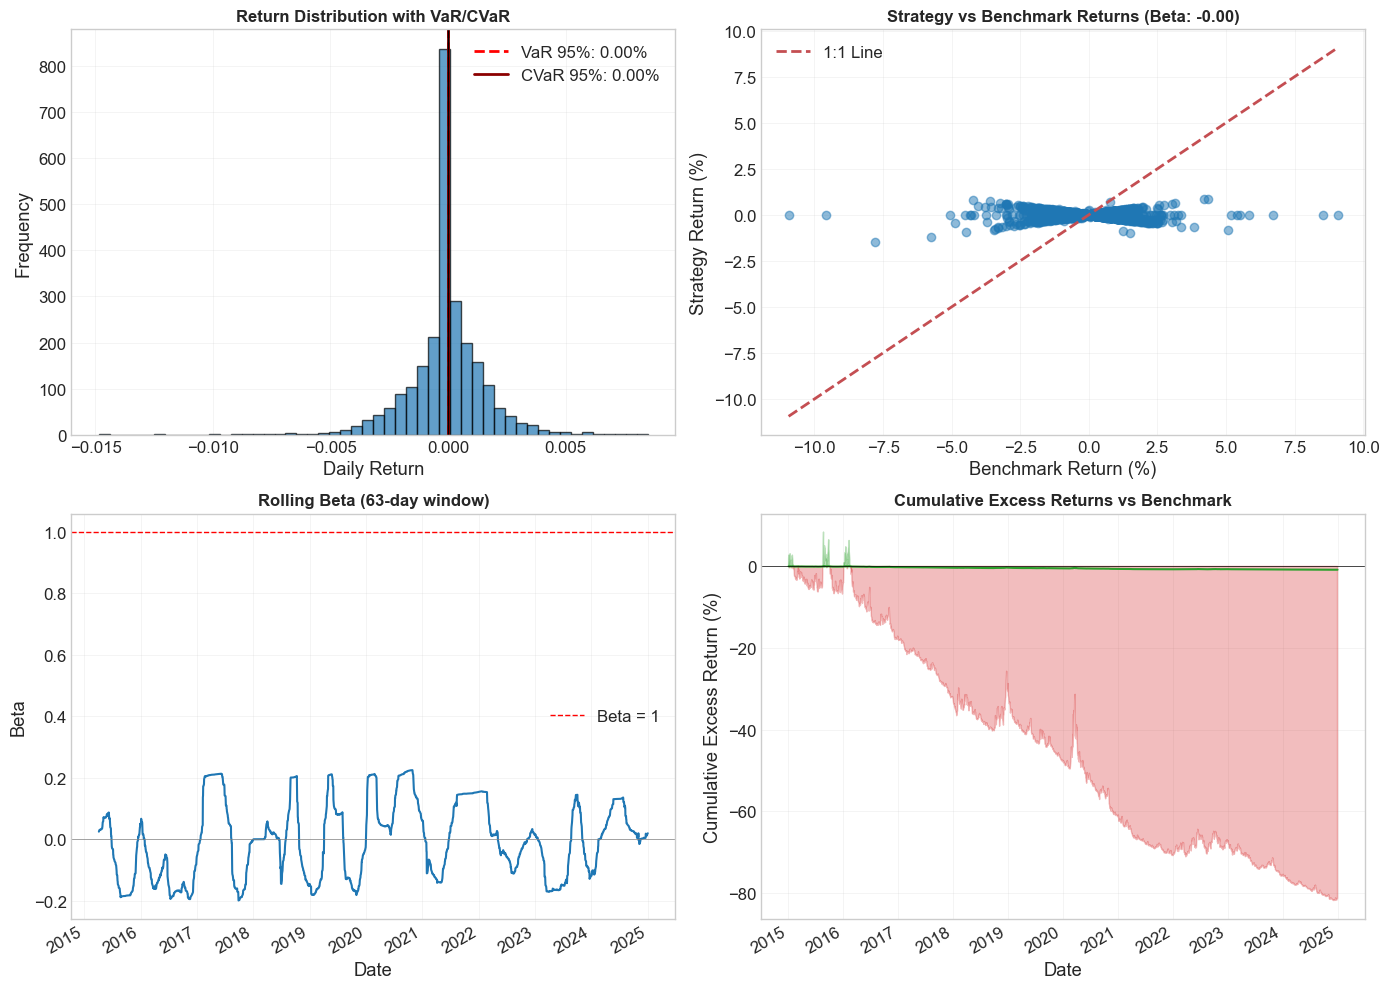

In [19]:
# Visualize risk metrics
if len(aligned_strategy) > 30 and 'risk_metrics' in dir():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Return distribution with VaR/CVaR
    ax1 = axes[0, 0]
    aligned_strategy.hist(bins=50, ax=ax1, color='#1f77b4', alpha=0.7, edgecolor='black')
    var_95 = risk_metrics.get('var_95', 0)
    cvar_95 = risk_metrics.get('cvar_95', 0)
    ax1.axvline(x=var_95, color='red', linestyle='--', linewidth=2, label=f'VaR 95%: {var_95*100:.2f}%')
    ax1.axvline(x=cvar_95, color='darkred', linestyle='-', linewidth=2, label=f'CVaR 95%: {cvar_95*100:.2f}%')
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax1.set_title('Return Distribution with VaR/CVaR', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Daily Return')
    ax1.set_ylabel('Frequency')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Strategy vs Benchmark scatter
    ax2 = axes[0, 1]
    ax2.scatter(aligned_benchmark * 100, aligned_strategy * 100, alpha=0.5, color='#1f77b4')
    ax2.plot([aligned_benchmark.min()*100, aligned_benchmark.max()*100], 
             [aligned_benchmark.min()*100, aligned_benchmark.max()*100], 
             'r--', linewidth=2, label='1:1 Line')
    beta = benchmark_metrics.get('beta', 1)
    ax2.set_title(f'Strategy vs Benchmark Returns (Beta: {beta:.2f})', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Benchmark Return (%)')
    ax2.set_ylabel('Strategy Return (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Rolling beta
    ax3 = axes[1, 0]
    window = CONFIG['risk']['rolling_beta_window']
    if len(aligned_strategy) > window:
        rolling_cov = aligned_strategy.rolling(window).cov(aligned_benchmark)
        rolling_var = aligned_benchmark.rolling(window).var()
        rolling_beta = rolling_cov / rolling_var
        rolling_beta.plot(ax=ax3, color='#1f77b4', linewidth=1.5)
        ax3.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Beta = 1')
        ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
        ax3.set_title(f'Rolling Beta ({window}-day window)', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Date')
        ax3.set_ylabel('Beta')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Insufficient data for rolling beta', ha='center', va='center')
        ax3.set_title('Rolling Beta (Insufficient Data)')
    
    # Cumulative excess returns
    ax4 = axes[1, 1]
    excess_returns = aligned_strategy - aligned_benchmark
    cumulative_excess = (1 + excess_returns).cumprod() - 1
    cumulative_excess.plot(ax=ax4, color='#2ca02c', linewidth=1.5)
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax4.fill_between(cumulative_excess.index, 0, cumulative_excess * 100, 
                     where=cumulative_excess >= 0, color='#2ca02c', alpha=0.3)
    ax4.fill_between(cumulative_excess.index, 0, cumulative_excess * 100, 
                     where=cumulative_excess < 0, color='#d62728', alpha=0.3)
    ax4.set_title('Cumulative Excess Returns vs Benchmark', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Cumulative Excess Return (%)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [20]:
# Save results
output_dir = project_root / CONFIG['output']['directory']
output_dir.mkdir(exist_ok=True)

print(f"\nResults can be found in: {output_dir}")
print(f"\nBacktest completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Results can be found in: C:\Dev\projects\investment_trying\reports

Backtest completed at: 2026-04-16 15:05:03


## Notes

### Strategy Overview
The Multi-Pattern Strategy uses confluence scoring from 20 different pattern detectors:
- **Basic Patterns**: MSL, Matching Lows, NR7 Inside Day, N-Bar Decline, Floor Pivot
- **Harmonic Patterns**: Gartley, ABC, Symmetric Triangle, Donchian, Bollinger
- **Complex Patterns**: Cup Handle, Head Shoulders, Spike Ledge, Three Hills, Parabolic Arc
- **Classic Patterns**: Double Top, Double Bottom, Trader Vic 2B, Triple Top, Dead Cat Bounce

### Interpretation
- Signals are generated when multiple patterns agree (confluence)
- Market regime filter adapts to bull/bear/sideways conditions
- Position sizing based on ATR and risk parameters

### Next Steps
- Parameter optimization
- Walk-forward analysis
- Compare with other timeframes
- Add sector/market filters